In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re


In [2]:
data = pd.read_csv("../data/concept_net.csv")

## Observation

In [ ]:
counts = data["relation"].value_counts(sort=True)
plt.bar(counts.index, counts.values)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
counts

In [ ]:
data.loc[data["relation"]=="/r/LocatedNear"]
# Changer LocatedNear en AtLocation

In [ ]:
# Changer les relations de la forme NotRel en Rel, et en mettant 'not_' devant le tail

In [ ]:
data.loc[data["relation"]=="/r/EtymologicallyDerivedFrom"][:5]
# Supprimer cette relation


In [ ]:
data.loc[data["relation"]=="/r/HasContext"].sort_values(by="weight", ascending = False)

## Pre-processing

### Relations

In [3]:
rel_del = ['/r/EtymologicallyDerivedFrom']
data = data[~data['relation'].isin(rel_del)]

In [4]:
mask_not = data['relation'].str.startswith('/r/Not', na=False)

data.loc[mask_not, 'tail'] = data.loc[mask_not, 'tail'].apply(
    lambda x: '/'.join(
        [part if i != 3 else 'not_' + part for i, part in enumerate(str(x).split('/'))]
    )
)

data.loc[mask_not, 'relation'] = data.loc[mask_not, 'relation'].str.replace('/r/Not', '/r/')

data[mask_not]

,id,relation,head,tail,weight
133805,133805,/r/CapableOf,/c/en/americans,/c/en/not_eat_cats,2.000
133806,133806,/r/CapableOf,/c/en/artichoke_hearts,/c/en/not_beat,2.000
133807,133807,/r/CapableOf,/c/en/atheists,/c/en/not_believe_god_exists,2.828
133808,133808,/r/CapableOf,/c/en/atheists,/c/en/not_believe_in_god,6.325
133809,133809,/r/CapableOf,/c/en/cats,/c/en/not_like_water,2.000
...,...,...,...,...,...
134232,134232,/r/HasProperty,/c/en/smoking,/c/en/not_good_for_health,3.464
134233,134233,/r/HasProperty,/c/en/woman_workaholic,/c/en/not_frivolous_and_flighty,2.000
134234,134234,/r/HasProperty,/c/en/world,/c/en/not_flat,2.000
134235,134235,/r/HasProperty,/c/en/world,/c/en/not_round,2.000


In [5]:
mapp_rename = {
    '/r/LocatedNear': '/r/AtLocation',
    '/r/HasLastSubevent' : '/r/HasSubevent',
    '/r/HasFirstSubevent' : '/r/HasSubevent'
}

data['relation'] = data['relation'].replace(mapp_rename)

In [6]:
symetric_rel = ['/r/Synonym', '/r/RelatedTo', '/r/SimilarTo', '/r/Antonym', '/r/DistinctFrom', '/r/MannerOf']

df_sym = data[data['relation'].isin(symetric_rel)].copy()
df_sym = df_sym.rename(columns={'head': 'tail', 'tail': 'head'})

data = pd.concat([data, df_sym], ignore_index=True)

data = data.drop_duplicates()

In [7]:
data['relation'] = data['relation'].str.removeprefix('/r/')

In [8]:
data = data.drop(columns=["id"])

### Entités

In [9]:
data['head'] = data['head'].str.removeprefix('/c/')
data['tail'] = data['tail'].str.removeprefix('/c/')

In [10]:
mask_en_fr = data['head'].str.startswith('en/', na=False) & data['tail'].str.startswith('fr/', na=False)

mask_fr_en = data['head'].str.startswith('fr/', na=False) & data['tail'].str.startswith('en/', na=False)

data_lang_asymetry = data[mask_en_fr | mask_fr_en]

data_lang_symetry = data[~(mask_en_fr | mask_fr_en)]

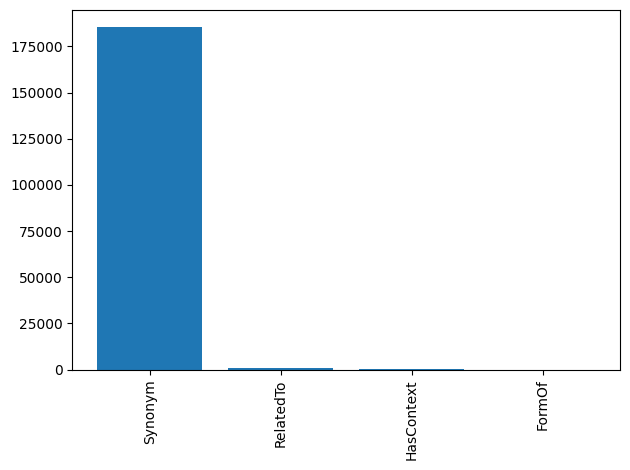

In [11]:
counts = data_lang_asymetry["relation"].value_counts(sort=True)
plt.bar(counts.index, counts.values)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

La relation Synonym semble servir pour la traduction. On va faire 3 csv, un pour 'en', un autre pour fr et le dernier pour la traduction.

In [12]:
data_en = data_lang_symetry[data_lang_symetry['head'].str.startswith('en/', na=False)].copy()
data_fr = data_lang_symetry[data_lang_symetry['head'].str.startswith('fr/', na=False)].copy()

data_en['head'] = data_en['head'].str.removeprefix('en/')
data_en['tail'] = data_en['tail'].str.removeprefix('en/')

data_fr['head'] = data_fr['head'].str.removeprefix('fr/')
data_fr['tail'] = data_fr['tail'].str.removeprefix('fr/')

In [13]:
data_translate = data_lang_asymetry.copy()

In [14]:
data_translate.shape[0] + data_en.shape[0] + data_fr.shape[0] == data.shape[0]
# pour verifier si le partage s'est bien fait

True

## Save

In [15]:
data_fr.to_csv("../data/concept_net_fr.csv")
data_en.to_csv("../data/concept_net_en.csv")
data_translate.to_csv("../data/concept_net_translate.csv")